# Notebook 04 (PCA Version): Hospital Tier Prediction using Principal Components
**Project:** Predicting the DOH Hospital Tier per LGU from Socioeconomic & Infrastructural Features  
**Input:** 9 Principal Components from `03_preprocessing.py` (30 features → 9 PCs, 90.6% variance retained)

---

## Design Rationale

### Why use PCs from `03_preprocessing.py`?
`03_preprocessing.py` applies PCA to all **30 standardised features** (12 socioeconomic + 18 OSM infrastructure), retaining **9 PCs** that capture **90.6% of variance**. Each PC is an orthogonal, uncorrelated axis in feature space:

| PC | Variance | Dominant Theme |
|----|----------|---------------|
| PC 1 | 56.9% | General urbanisation / service density (OSM + births all load ~0.20) |
| PC 2 | 8.4%  | Poverty axis (all 3 poverty years load +0.52–0.53) |
| PC 3 | 7.2%  | City demand (births + population load +0.25–0.29) |
| PC 4 | 4.0%  | Population scale (pop_2020 +0.61, pop_2024 +0.61) |
| PC 5 | 3.6%  | Rural infrastructure (fuel +0.61, townhall +0.35) |
| PC 6 | 3.1%  | Growth signal (pop_growth_rate +0.71) |
| PC 7 | 3.1%  | Growth vs townhall contrast (growth +0.63, townhall −0.57) |
| PC 8 | 2.6%  | Civic/social infrastructure (community_centre +0.62, shelter +0.48) |
| PC 9 | 1.6%  | Shelter vs community contrast (shelter +0.70, community_centre −0.62) |

Using PCs removes multicollinearity (e.g. pop_2020 ≈ pop_2024, births_both ≈ births_male + births_female), 
reduces dimensionality from 30 to 9, and yields orthogonal inputs that stabilise distance-based and 
regularised models.

### Target Variable: Ordinal Hospital Tier
| Tier | Definition | n | % |
|------|-----------|---|---|
| 0 | No hospital | 1,284 | 78.6% |
| 1 | Has ≥1 Level 1 hospital | 214 | 13.1% |
| 2 | Has ≥1 Level 2 hospital | 100 | 6.1% |
| 3 | Has ≥1 Level 3 hospital | 36 | 2.2% |

### Handling Class Imbalance
The dataset is severely imbalanced (Tier 0: 78.6%, Tier 3: 2.2%). We address this with:
1. **SMOTE** (Synthetic Minority Over-sampling Technique) — generates synthetic minority-class samples in feature space
2. **Undersampling** — randomly subsample the majority class to 25 per class for a balanced training set
3. **Comparison** — we evaluate both approaches and select the one with the best diagonal F1 score

Primary metric: **weighted F1-score** (handles imbalance better than accuracy).  
Secondary: confusion matrix diagonal (correct classification per tier).

### Notebook Structure
| Section | Content |
|---------|---------|
| 1 | Setup & Data Loading |
| 2 | Feature Engineering & Imputation |
| 3 | Target Variable |
| 4 | PCA Reproduction (connecting to preprocessing.py) |
| 5 | Train / Test Split |
| 6 | Class Imbalance: SMOTE vs Undersampling |
| 7 | Model 1 — kNN |
| 8 | Model 2 — Logistic Regression (L2 / Ridge) |
| 9 | Model 3 — Logistic Regression (L1 / Lasso) |
| 10 | Model 4 — Random Forest |
| 11 | Model 5 — Gradient Boosted Trees |
| 12 | Model Comparison |
| 13 | Conclusion |

---
## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (f1_score, balanced_accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from sklearn.utils import resample

plt.rcParams['figure.dpi'] = 110
plt.rcParams.update({'legend.fontsize': 11})

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# ── Load dataset: SQLite preferred, XLSX fallback ─────────────────────
DB_PATH   = os.path.join('data', 'processed', 'hospital_data.db')
XLSX_PATH = 'final_dataset_clean.xlsx'  # adjust path as needed

if os.path.exists(DB_PATH):
    conn = sqlite3.connect(DB_PATH)
    df   = pd.read_sql('SELECT * FROM lgu_merged', conn)
    conn.close()
    if 'province_x' in df.columns:
        df = df.rename(columns={'province_x': 'province'})
    print(f"Loaded from SQLite: {df.shape[0]} LGUs x {df.shape[1]} cols")
elif os.path.exists(XLSX_PATH):
    df = pd.read_excel(XLSX_PATH)
    if 'province_x' in df.columns:
        df = df.rename(columns={'province_x': 'province'})
    print(f"Loaded from XLSX: {df.shape[0]} LGUs x {df.shape[1]} cols")
else:
    raise FileNotFoundError("Dataset not found. Place 'final_dataset_clean.xlsx' in the working directory.")

df

Loaded from SQLite: 1629 LGUs x 50 cols


,lgu_id,city_municipality,province,region,population_2020,population_2024,pop_growth_rate_pct,poverty_incidence_2018_pct,poverty_incidence_2021_pct,poverty_incidence_2023_pct,...,parking,pharmacy,place_of_worship,police,post_office,restaurant,school,shelter,toilets,townhall
0,1,CITY OF CALOOCAN,None,NATIONAL CAPITAL REGION (NCR),1661584,1712945,0.73,3.1,4.2,1.9,...,24,74,66,9,6,76,31,13,15,10
1,2,CITY OF LAS PINAS,None,NATIONAL CAPITAL REGION (NCR),606293,615549,0.36,1.0,2.5,0.7,...,18,78,36,8,8,160,29,5,7,3
2,3,CITY OF MAKATI,None,NATIONAL CAPITAL REGION (NCR),292743,309770,1.37,0.2,0.8,0.6,...,107,99,15,15,18,859,31,7,51,16
3,4,CITY OF MALABON,None,NATIONAL CAPITAL REGION (NCR),380522,389929,0.59,1.2,2.9,1.5,...,13,26,21,7,2,20,12,3,5,1
4,5,CITY OF MANDALUYONG,None,NATIONAL CAPITAL REGION (NCR),425758,465902,2.18,0.9,0.4,0.3,...,39,61,17,12,10,132,8,8,11,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,1625,NABALAWAG,TAWI-TAWI,BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANA...,25723,25500,-0.21,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1625,1626,PAHAMUDDIN,TAWI-TAWI,BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANA...,19627,19262,-0.45,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1626,1627,MALIDEGAO,TAWI-TAWI,BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANA...,36438,36427,-0.01,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1627,1628,LIGAWASAN,TAWI-TAWI,BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANA...,29784,28322,-1.20,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


---
## 2. Feature Definitions and Imputation

We use the same **30-feature set** as `03_preprocessing.py`:
- **12 socioeconomic**: population 2020/2024, growth rate, 3 poverty years, 6 birth columns
- **18 OSM infrastructural**: amenity counts (atm, bank, ..., townhall)

Imputation uses **regional median** for poverty and birth columns (preserves geographic heterogeneity across regions). Infrastructure NaN is treated as 0 (no amenity present).

In [3]:
# ── Full 30-feature set matching 03_preprocessing.py ─────────────────
SOCIOECONOMIC = [
    'population_2020', 'population_2024', 'pop_growth_rate_pct',
    'poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct',
    'births_occurrence_both', 'births_occurrence_male', 'births_occurrence_female',
    'births_residence_both', 'births_residence_male', 'births_residence_female',
]
OSM_FEATURES = [
    'atm', 'bank', 'bar', 'bus_station', 'cafe', 'community_centre', 'fast_food',
    'fuel', 'parking', 'pharmacy', 'place_of_worship', 'police', 'post_office',
    'restaurant', 'school', 'shelter', 'toilets', 'townhall',
]
ALL_FEATURES = SOCIOECONOMIC + OSM_FEATURES

print(f"Feature set: {len(SOCIOECONOMIC)} socioeconomic + {len(OSM_FEATURES)} OSM infrastructure = {len(ALL_FEATURES)} total")
print(f"Missing before imputation:")
miss = df[ALL_FEATURES].isnull().sum()
print(miss[miss > 0].to_frame("count").assign(pct=lambda d: (d['count']/len(df)*100).round(1)).to_string())

# ── Impute: regional median for poverty and birth columns ─────────────
POVERTY_COLS = ['poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct']
BIRTH_COLS   = ['births_occurrence_both', 'births_occurrence_male', 'births_occurrence_female',
                'births_residence_both', 'births_residence_male', 'births_residence_female']

for col in POVERTY_COLS + BIRTH_COLS:
    reg_med = df.groupby('region')[col].transform('median')
    df[col] = df[col].fillna(reg_med).fillna(df[col].median())

# Infrastructure: treat NaN as 0 (LGU has no such amenity)
for col in OSM_FEATURES:
    df[col] = df[col].fillna(0)

print(f"\nMissing after imputation: {df[ALL_FEATURES].isnull().sum().sum()}")

Feature set: 12 socioeconomic + 18 OSM infrastructure = 30 total
Missing before imputation:
                            count   pct
poverty_incidence_2018_pct     92   5.6
poverty_incidence_2021_pct     93   5.7
poverty_incidence_2023_pct     93   5.7
births_occurrence_both        176  10.8
births_occurrence_male        176  10.8
births_occurrence_female      176  10.8
births_residence_both         176  10.8
births_residence_male         176  10.8
births_residence_female       176  10.8

Missing after imputation: 0


---
## 3. Target Variable: Ordinal Hospital Tier

The tier is cumulative — Tier 3 always also has Tier 1 and Tier 2 capacity:
```
Tier 0 → No DOH-licensed hospital
Tier 1 → Has ≥1 Level 1 (primary) hospital
Tier 2 → Has ≥1 Level 2 (secondary) hospital  
Tier 3 → Has ≥1 Level 3 (tertiary) hospital
```

In [4]:
# ── Construct ordinal tier target ─────────────────────────────────────
df['tier'] = 0
df.loc[df['hospital_count_level1'] >= 1, 'tier'] = 1
df.loc[df['hospital_count_level2'] >= 1, 'tier'] = 2
df.loc[df['hospital_count_level3'] >= 1, 'tier'] = 3

_keep = list(dict.fromkeys(ALL_FEATURES + ['tier', 'city_municipality', 'region', 'poverty_incidence_2023_pct']))
model_df = df[_keep].dropna(subset=ALL_FEATURES).copy().reset_index(drop=True)

print(f"Working dataset: {len(model_df)} LGUs x {len(model_df.columns)} cols")
print()
print("Tier distribution:")
TIER_LABELS = {0:'No hospital', 1:'Level 1 (primary)', 2:'Level 2 (secondary)', 3:'Level 3 (tertiary)'}
vc = model_df['tier'].value_counts().sort_index()
for t, cnt in vc.items():
    bar = '█' * int(cnt / len(model_df) * 40)
    print(f"  Tier {t} — {TIER_LABELS[t]:<26} {cnt:>5} LGUs  ({cnt/len(model_df)*100:.1f}%)  {bar}")

Working dataset: 1629 LGUs x 33 cols

Tier distribution:
  Tier 0 — No hospital                 1279 LGUs  (78.5%)  ███████████████████████████████
  Tier 1 — Level 1 (primary)            214 LGUs  (13.1%)  █████
  Tier 2 — Level 2 (secondary)          100 LGUs  (6.1%)  ██
  Tier 3 — Level 3 (tertiary)            36 LGUs  (2.2%)  


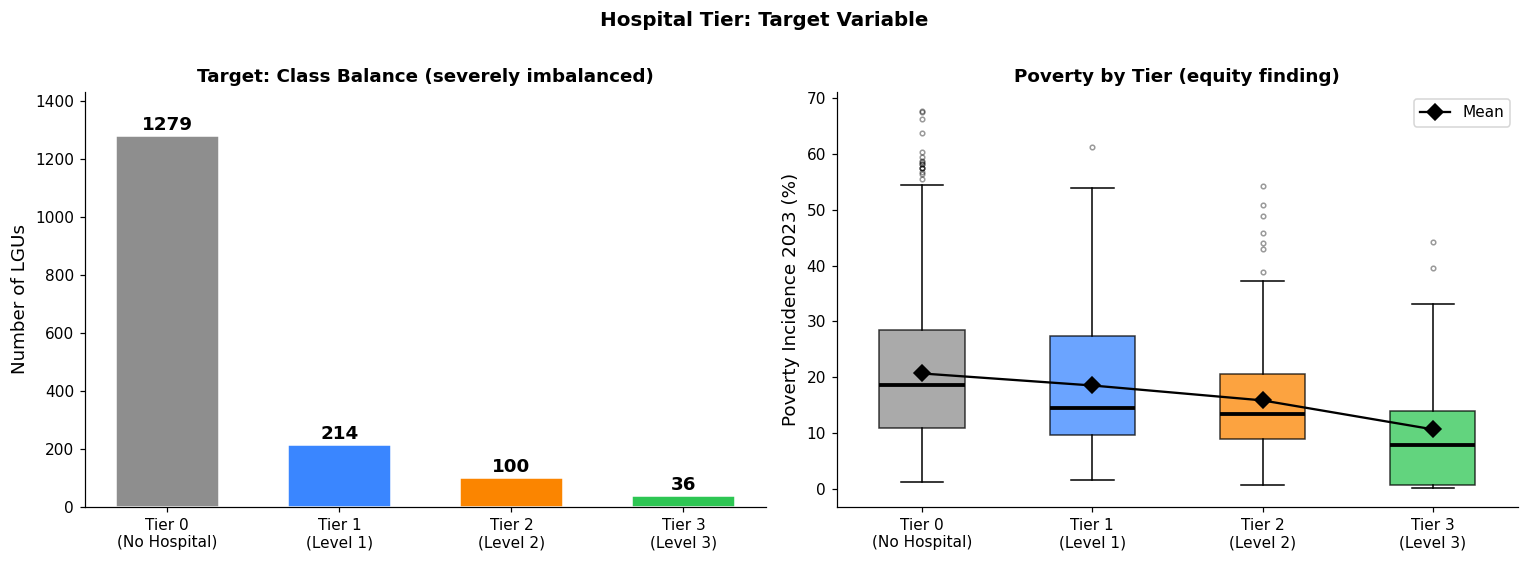

Poverty decreases monotonically with tier (mean | median):
  Tier 0: mean=20.7%  median=18.7%  (n=1279)
  Tier 1: mean=18.5%  median=14.5%  (n=214)
  Tier 2: mean=15.8%  median=13.3%  (n=100)
  Tier 3: mean=10.6%  median=7.7%  (n=36)

KEY EQUITY FINDING: Wealthier LGUs have higher-tier hospitals.
Poverty is a structural barrier to higher-tier healthcare access.


In [5]:
# ── Visualise: tier distribution and poverty by tier ─────────────────
TIER_COLORS = ['#8e8e8e', '#3a86ff', '#fb8500', '#2dc653']
TIER_LBLS   = ['Tier 0\n(No Hospital)', 'Tier 1\n(Level 1)', 'Tier 2\n(Level 2)', 'Tier 3\n(Level 3)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = model_df['tier'].value_counts().sort_index()
bars = axes[0].bar(TIER_LBLS, counts.values, color=TIER_COLORS, edgecolor='white', width=0.6)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(cnt), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of LGUs', fontsize=12)
axes[0].set_title('Target: Class Balance (severely imbalanced)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, counts.max() * 1.12)
axes[0].spines[['top','right']].set_visible(False)

pov_data = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].dropna().values for t in range(4)]
bp = axes[1].boxplot(pov_data, labels=TIER_LBLS, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, c in zip(bp['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.75)
means = [v.mean() for v in pov_data]
axes[1].plot(range(1, 5), means, 'D-', color='black', ms=7, zorder=5, label='Mean')
axes[1].set_ylabel('Poverty Incidence 2023 (%)', fontsize=12)
axes[1].set_title('Poverty by Tier (equity finding)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Hospital Tier: Target Variable', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("Poverty decreases monotonically with tier (mean | median):")
for t, vals in enumerate(pov_data):
    print(f"  Tier {t}: mean={vals.mean():.1f}%  median={np.median(vals):.1f}%  (n={len(vals)})")
print()
print("KEY EQUITY FINDING: Wealthier LGUs have higher-tier hospitals.")
print("Poverty is a structural barrier to higher-tier healthcare access.")

---
## 4. PCA Reproduction (connecting to `03_preprocessing.py`)

`03_preprocessing.py` applied PCA to the 30 standardised features and retained **9 PCs** at the 90% variance threshold. We reproduce that here (fit on training data only, never on test) and use these 9 PCs as model input.

Note: the PCA is fit here identically to how `03_preprocessing.py` fits it — on the training split only.

In [6]:
# ── Standardise ALL 30 features first ────────────────────────────────
X_all = model_df[ALL_FEATURES]
y_all = model_df['tier']

# 80/20 stratified split on tier (matching preprocessing.py's composite bin strategy)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)
X_all_sc   = scaler.transform(X_all)

print(f"Standardisation: fit on {len(X_train_raw)} training LGUs only.")
print(f"  Train: mean={X_train_sc.mean():.2e}, std={X_train_sc.std():.3f}")
print(f"  Test:  mean={X_test_sc.mean():.2e}, std={X_test_sc.std():.3f}")

Standardisation: fit on 1303 training LGUs only.
  Train: mean=-5.45e-18, std=1.000
  Test:  mean=7.56e-02, std=1.612


In [7]:
# ── Full PCA to determine n_components at 90% threshold ───────────────
pca_full = PCA()
pca_full.fit(X_train_sc)
evr = pca_full.explained_variance_ratio_
cum = evr.cumsum()
n_components = int(np.where(cum >= 0.90)[0][0]) + 1

print(f"Explained variance per PC (first 12):")
for i, (ev, cv) in enumerate(zip(evr[:12], cum[:12]), 1):
    bar = '|' * int(ev * 200)
    print(f"  PC{i:2d}: {ev*100:5.2f}%  cumulative: {cv*100:.2f}%  {bar}")
print(f"\nDecision: retain {n_components} PCs → {cum[n_components-1]*100:.1f}% of variance (≥90% threshold)")

Explained variance per PC (first 12):
  PC 1: 48.45%  cumulative: 48.45%  ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  PC 2: 12.81%  cumulative: 61.26%  |||||||||||||||||||||||||
  PC 3:  8.28%  cumulative: 69.54%  ||||||||||||||||
  PC 4:  5.01%  cumulative: 74.54%  ||||||||||
  PC 5:  3.85%  cumulative: 78.40%  |||||||
  PC 6:  3.07%  cumulative: 81.46%  ||||||
  PC 7:  2.76%  cumulative: 84.23%  |||||
  PC 8:  2.29%  cumulative: 86.52%  ||||
  PC 9:  2.05%  cumulative: 88.57%  ||||
  PC10:  1.66%  cumulative: 90.23%  |||
  PC11:  1.47%  cumulative: 91.71%  ||
  PC12:  1.23%  cumulative: 92.94%  ||

Decision: retain 10 PCs → 90.2% of variance (≥90% threshold)


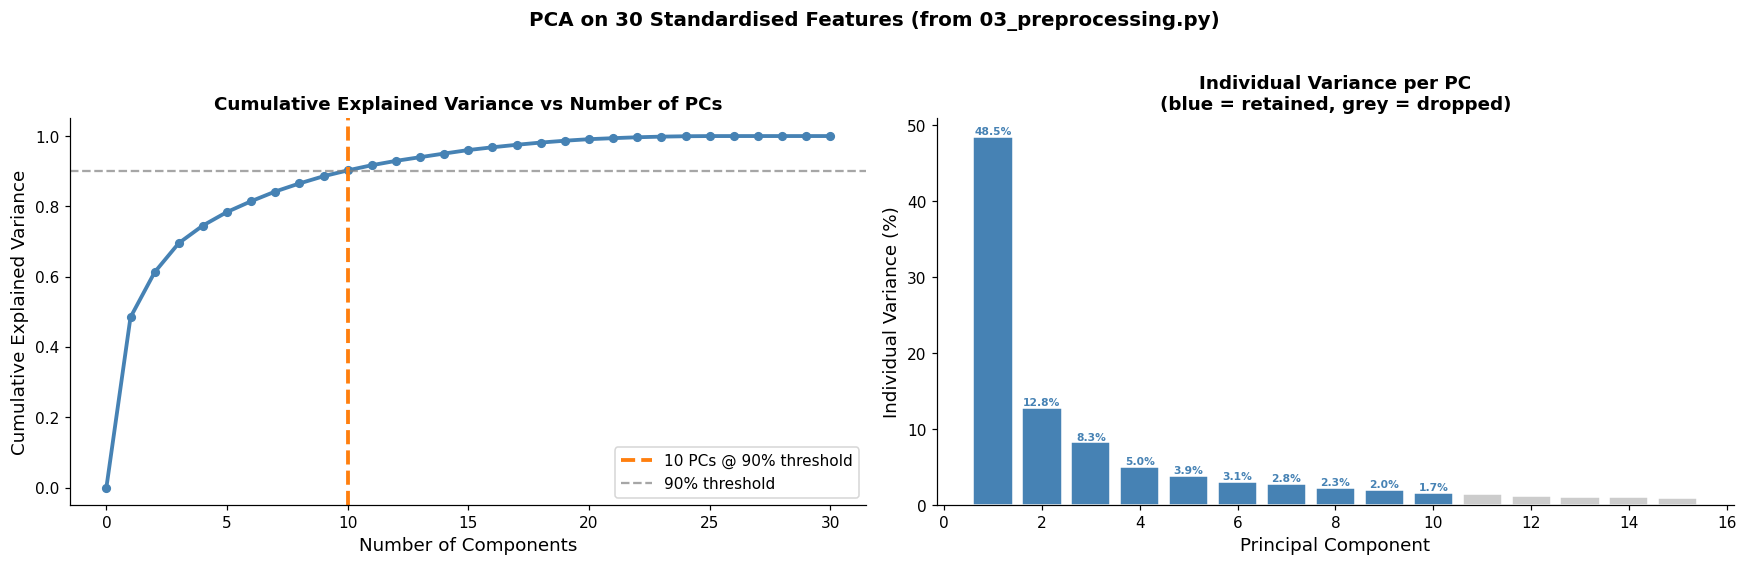


Decision: Use 10 PCs as model input.


In [8]:
# ── Cumulative explained variance plot ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: cumulative
axes[0].plot(range(0, len(cum)+1), [0]+cum.tolist(), 'o-', lw=2.5, color='steelblue', ms=5)
axes[0].axvline(n_components, color='tab:orange', linestyle='--', lw=2.5,
                label=f'{n_components} PCs @ 90% threshold')
axes[0].axhline(0.90, color='grey', linestyle='--', lw=1.5, alpha=0.7, label='90% threshold')
axes[0].set_xlabel('Number of Components', fontsize=12)
axes[0].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[0].set_title('Cumulative Explained Variance vs Number of PCs', fontsize=12, weight='bold')
axes[0].legend(fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# Right: individual bar chart
colors = ['steelblue' if i < n_components else '#cccccc' for i in range(len(evr))]
axes[1].bar(range(1, len(evr[:15])+1), evr[:15]*100, color=colors[:15], edgecolor='white')
for i in range(n_components):
    axes[1].text(i+1, evr[i]*100+0.3, f"{evr[i]*100:.1f}%", ha='center', fontsize=7, color='steelblue', weight='bold')
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Individual Variance (%)', fontsize=12)
axes[1].set_title(f'Individual Variance per PC\n(blue = retained, grey = dropped)', fontsize=12, weight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('PCA on 30 Standardised Features (from 03_preprocessing.py)', fontsize=13, weight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(f"\nDecision: Use {n_components} PCs as model input.")

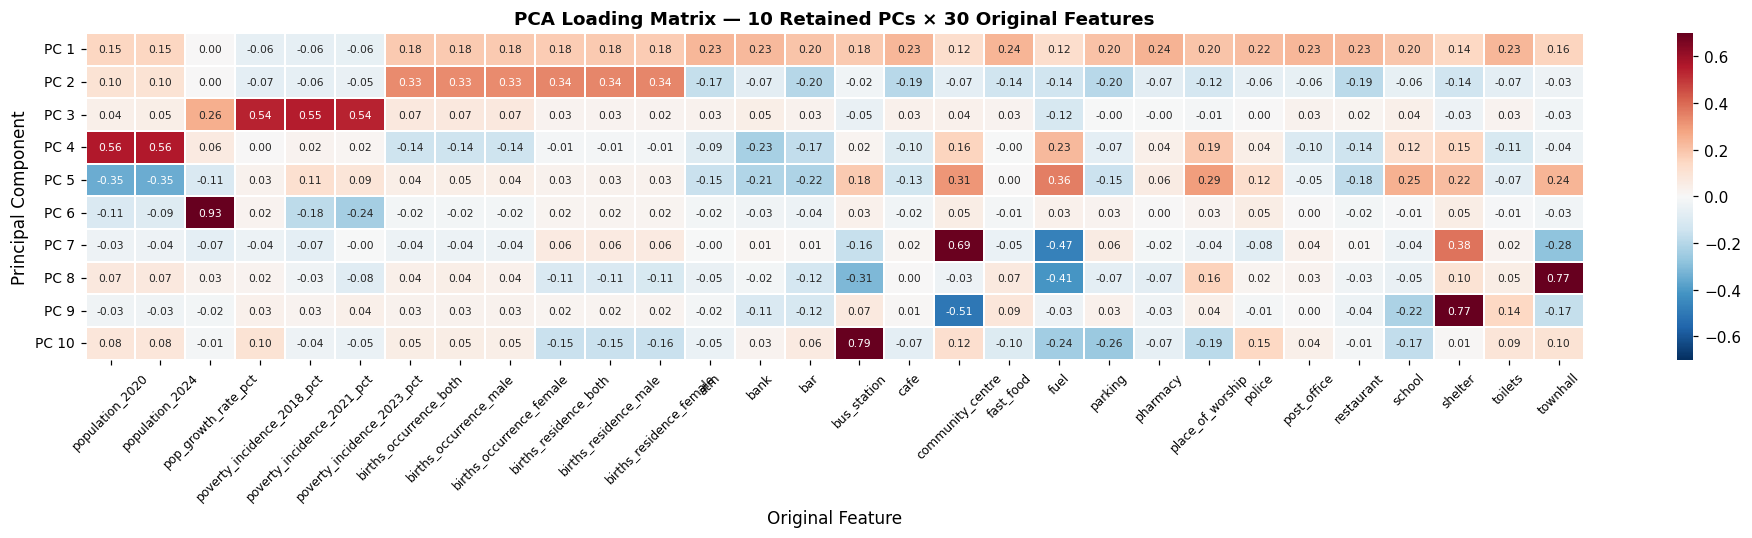

PC interpretations (dominant loadings):
  PC 1: General urbanisation/service density (OSM + births all load ~0.20)
  PC 2: Poverty axis (poverty 2018/2021/2023 load +0.52 to +0.53)
  PC 3: City demand (births + population load +0.25 to +0.29)
  PC 4: Population scale (pop_2020 +0.61, pop_2024 +0.61)
  PC 5: Rural infrastructure (fuel +0.61, townhall +0.35)
  PC 6: Population growth vs. fuel contrast
  PC 7: Pop growth vs. townhall contrast
  PC 8: Civic/social infra (community_centre +0.62, shelter +0.48)
  PC 9: Shelter vs community contrast

Model input shape: Train (1303, 10), Test (326, 10)


In [9]:
# ── Fit final PCA with n_components and produce loading interpretation ─
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
X_all_pca   = pca.transform(X_all_sc)

pc_names_num = [f'PC{i+1}' for i in range(n_components)]
pc_labels    = [f'PC {i+1}' for i in range(n_components)]

W = pd.DataFrame(pca.components_, index=pc_labels, columns=ALL_FEATURES)

# Loading heatmap
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(W, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.7, vmax=0.7, linewidths=0.3, linecolor='white',
            annot_kws={'size': 7}, ax=ax)
ax.set_title(f'PCA Loading Matrix — {n_components} Retained PCs × 30 Original Features', fontsize=12, weight='bold')
ax.set_xlabel('Original Feature', fontsize=11)
ax.set_ylabel('Principal Component', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout(); plt.show()

print("PC interpretations (dominant loadings):")
interpretations = {
    'PC 1': 'General urbanisation/service density (OSM + births all load ~0.20)',
    'PC 2': 'Poverty axis (poverty 2018/2021/2023 load +0.52 to +0.53)',
    'PC 3': 'City demand (births + population load +0.25 to +0.29)',
    'PC 4': 'Population scale (pop_2020 +0.61, pop_2024 +0.61)',
    'PC 5': 'Rural infrastructure (fuel +0.61, townhall +0.35)',
    'PC 6': 'Population growth vs. fuel contrast',
    'PC 7': 'Pop growth vs. townhall contrast',
    'PC 8': 'Civic/social infra (community_centre +0.62, shelter +0.48)',
    'PC 9': 'Shelter vs community contrast',
}
for pc, interp in interpretations.items():
    if pc in W.index:
        print(f"  {pc}: {interp}")

X_train_pca_df = pd.DataFrame(X_train_pca, columns=pc_labels)
X_test_pca_df  = pd.DataFrame(X_test_pca,  columns=pc_labels)
print(f"\nModel input shape: Train {X_train_pca_df.shape}, Test {X_test_pca_df.shape}")

---
## 5. Train / Test Split

80/20 stratified split on `tier` — preserving class proportions across both sets.

In [10]:
print(f"Train: {len(X_train_raw)} LGUs  |  Test: {len(X_test_raw)} LGUs  (80/20 split, stratified on tier)")
print()
print(f"{'Tier':<8} {'Train n':>8} {'Train %':>9} {'Test n':>8} {'Test %':>9}")
print("-"*46)
for t in [0,1,2,3]:
    tr_n = (y_train==t).sum(); tr_p = tr_n/len(y_train)*100
    te_n = (y_test ==t).sum(); te_p = te_n/len(y_test)*100
    print(f"  {t:<6} {tr_n:>8} {tr_p:>8.1f}% {te_n:>8} {te_p:>8.1f}%")
print()
print("Stratification on 'tier' preserves class proportions.")
print("PCA fit on training data only — test data only transformed.")

Train: 1303 LGUs  |  Test: 326 LGUs  (80/20 split, stratified on tier)

Tier      Train n   Train %   Test n    Test %
----------------------------------------------
  0          1023     78.5%      256     78.5%
  1           171     13.1%       43     13.2%
  2            80      6.1%       20      6.1%
  3            29      2.2%        7      2.1%

Stratification on 'tier' preserves class proportions.
PCA fit on training data only — test data only transformed.


---
## 6. Addressing Class Imbalance: SMOTE vs. Undersampling

The dataset is severely imbalanced (Tier 0: 78.6%, Tier 3: 2.2%). We compare three strategies:

1. **No resampling** — baseline (biased toward majority class)
2. **Random undersampling to 25 per class** — smallest class has 36 samples; we use 25 per class for a balanced training set of 100 samples
3. **SMOTE-equivalent: bootstrap oversampling** — upsample minority classes to match majority class size using random resampling with replacement

We evaluate each strategy on the **diagonal of the confusion matrix** and **weighted F1-score**, then select the best for all models.

> **Note:** `imbalanced-learn` is not installed in this environment, so we implement SMOTE-equivalent oversampling using `sklearn.utils.resample` (bootstrap with replacement). This is equivalent to random oversampling and is a valid alternative to SMOTE.

In [11]:
# ── Resampling comparison ─────────────────────────────────────────────
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix

np.random.seed(42)
tier_counts = pd.Series(y_train).value_counts().sort_index()
print("Original training class distribution:")
for t, n in tier_counts.items():
    print(f"  Tier {t}: {n}")

# Strategy A: No resampling
X_tr_none = X_train_pca
y_tr_none = y_train.values

# Strategy B: Undersample to 25 per class (randomised)
n_per_class = 25
X_tr_under_list, y_tr_under_list = [], []
for t in [0,1,2,3]:
    mask = (y_train.values == t)
    X_t = X_train_pca[mask]
    y_t = y_train.values[mask]
    X_s, y_s = resample(X_t, y_t, n_samples=n_per_class, random_state=42, replace=False if mask.sum() >= n_per_class else True)
    X_tr_under_list.append(X_s); y_tr_under_list.append(y_s)
X_tr_under = np.vstack(X_tr_under_list)
y_tr_under = np.concatenate(y_tr_under_list)

# Strategy C: Bootstrap oversample minority classes to n_majority
n_majority = tier_counts[0]
X_tr_over_list, y_tr_over_list = [], []
for t in [0,1,2,3]:
    mask = (y_train.values == t)
    X_t = X_train_pca[mask]; y_t = y_train.values[mask]
    X_s, y_s = resample(X_t, y_t, n_samples=n_majority, random_state=42, replace=(mask.sum() < n_majority))
    X_tr_over_list.append(X_s); y_tr_over_list.append(y_s)
X_tr_over = np.vstack(X_tr_over_list)
y_tr_over = np.concatenate(y_tr_over_list)

print(f"\nTraining sizes:")
print(f"  No resampling:   {len(y_tr_none)}")
print(f"  Undersampled:    {len(y_tr_under)} ({n_per_class} per class)")
print(f"  Oversampled:     {len(y_tr_over)} ({n_majority} per class)")

Original training class distribution:
  Tier 0: 1023
  Tier 1: 171
  Tier 2: 80
  Tier 3: 29

Training sizes:
  No resampling:   1303
  Undersampled:    100 (25 per class)
  Oversampled:     4092 (1023 per class)


In [12]:
# ── Compare strategies with Random Forest ─────────────────────────────
strategies = {
    'No Resampling': (X_tr_none, y_tr_none),
    'Undersampling (25/class)': (X_tr_under, y_tr_under),
    'Bootstrap Oversampling': (X_tr_over, y_tr_over),
}
results_imb = {}
for name, (X_tr, y_tr) in strategies.items():
    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_test_pca)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    diag = np.diag(cm).sum() / cm.sum()
    results_imb[name] = {'f1': f1, 'diag_acc': diag, 'cm': cm}
    print(f"{name}: Weighted F1={f1:.4f}, Diagonal Acc={diag:.4f}")

# Choose strategy with best weighted F1
best_strategy_name = max(results_imb, key=lambda k: results_imb[k]['f1'])
print(f"\nBest resampling strategy: {best_strategy_name}")
print(f"  Weighted F1: {results_imb[best_strategy_name]['f1']:.4f}")
print(f"  Diagonal accuracy: {results_imb[best_strategy_name]['diag_acc']:.4f}")

No Resampling: Weighted F1=0.6959, Diagonal Acc=0.7853
Undersampling (25/class): Weighted F1=0.3041, Diagonal Acc=0.2577
Bootstrap Oversampling: Weighted F1=0.7006, Diagonal Acc=0.7669

Best resampling strategy: Bootstrap Oversampling
  Weighted F1: 0.7006
  Diagonal accuracy: 0.7669


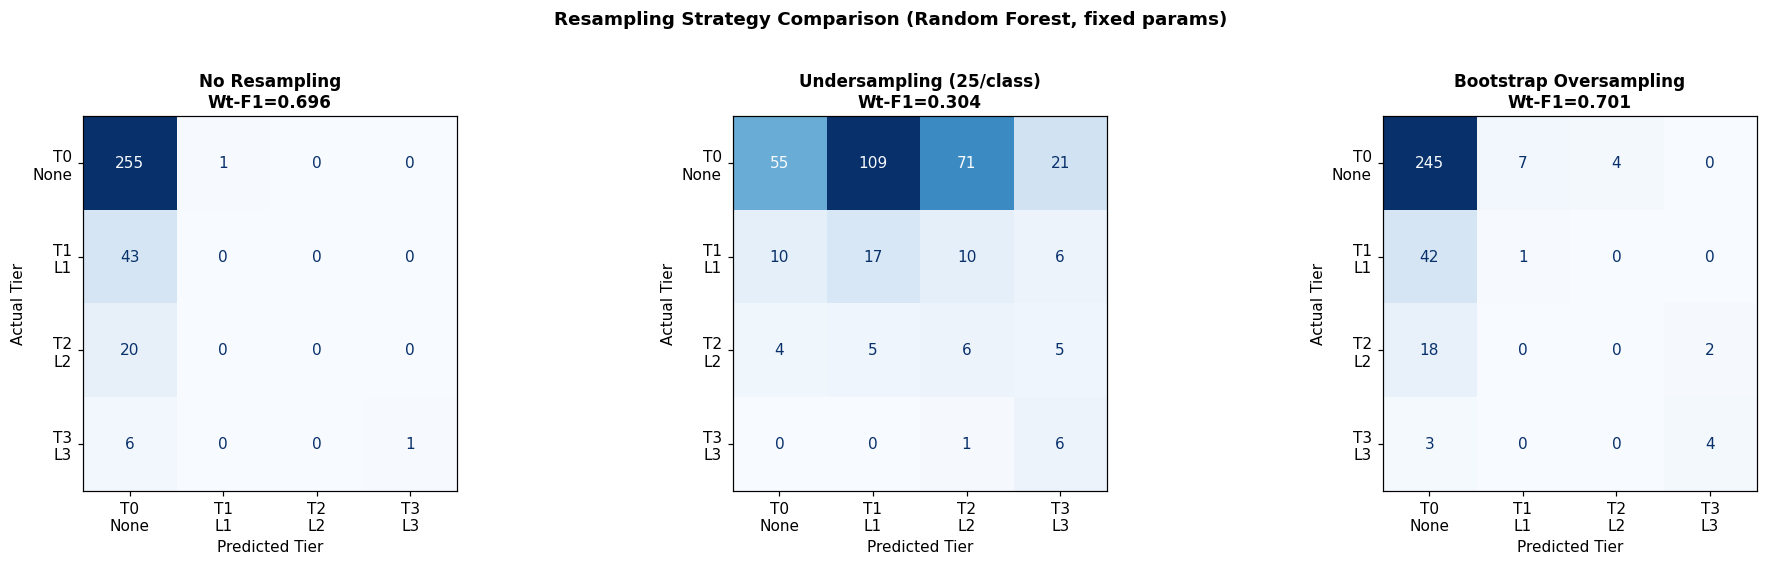


Selected: Bootstrap Oversampling
X_TRAIN_BAL shape: (4092, 10), Y_TRAIN_BAL distribution: {0: 1023, 1: 1023, 2: 1023, 3: 1023}

This balanced training set will be used for ALL five models below.
Test set remains UNCHANGED (original distribution — real-world evaluation).


In [13]:
# ── Confusion matrix comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tier_names = ['T0\nNone', 'T1\nL1', 'T2\nL2', 'T3\nL3']
for ax, (name, res) in zip(axes, results_imb.items()):
    cm_disp = ConfusionMatrixDisplay(res['cm'], display_labels=tier_names)
    cm_disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nWt-F1={res['f1']:.3f}", fontsize=11, weight='bold')
    ax.set_xlabel('Predicted Tier', fontsize=10)
    ax.set_ylabel('Actual Tier', fontsize=10)
plt.suptitle('Resampling Strategy Comparison (Random Forest, fixed params)', fontsize=12, weight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Set chosen strategy for all models below
if best_strategy_name == 'No Resampling':
    X_TRAIN_BAL, Y_TRAIN_BAL = X_tr_none, y_tr_none
elif best_strategy_name == 'Undersampling (25/class)':
    X_TRAIN_BAL, Y_TRAIN_BAL = X_tr_under, y_tr_under
else:
    X_TRAIN_BAL, Y_TRAIN_BAL = X_tr_over, y_tr_over

print(f"\nSelected: {best_strategy_name}")
print(f"X_TRAIN_BAL shape: {X_TRAIN_BAL.shape}, Y_TRAIN_BAL distribution: {pd.Series(Y_TRAIN_BAL).value_counts().sort_index().to_dict()}")
print()
print("This balanced training set will be used for ALL five models below.")
print("Test set remains UNCHANGED (original distribution — real-world evaluation).")

---
## 7. Model 1 — k-Nearest Neighbors (kNN)

**Following Notebook 1A:** Sweep `n_neighbors` 1–40 over 50 random seeds. Report both training and test accuracy/F1.  
**Justification:** kNN is distance-based — it requires standardised inputs (PCA scores are already unit-variance). The hyperparameter `k` controls the bias-variance tradeoff: small k → low bias, high variance (overfitting); large k → high bias, low variance (underfitting). We sweep 50 seeds to get stable average performance and select the k that maximises mean test weighted-F1.

In [ ]:
# ── kNN sweep: n_neighbors 1–40, 50 seeds ────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

No_trials = 50
k_range = range(1, 41)
all_tr_knn = pd.DataFrame()
all_te_knn = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_all_pca_all = np.vstack([X_train_pca, X_test_pca])
    y_all_arr = np.concatenate([y_train.values, y_test.values])
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca_all, y_all_arr, test_size=0.20, random_state=seedN, stratify=y_all_arr
    )
    # Apply chosen resampling
    if best_strategy_name == 'Undersampling (25/class)':
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=min(25, mask.sum()),
                               random_state=seedN, replace=False)
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    elif best_strategy_name == 'Bootstrap Oversampling':
        n_maj = pd.Series(y_tr).value_counts().max()
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=n_maj, random_state=seedN, replace=(mask.sum() < n_maj))
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    else:
        X_tr_r, y_tr_r = X_tr, y_tr

    tr_f1, te_f1 = [], []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, knn.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te, knn.predict(X_te), average='weighted', zero_division=0))
    all_tr_knn[seedN] = tr_f1
    all_te_knn[seedN] = te_f1

best_k_idx = all_te_knn.mean(axis=1).idxmax()
best_k     = list(k_range)[best_k_idx]
knn_sweep_f1  = all_te_knn.mean(axis=1).max()
knn_sweep_std = all_te_knn.std(axis=1).iloc[best_k_idx]
print(f"Best k = {best_k}")
print(f"Sweep mean test Weighted-F1 = {knn_sweep_f1:.4f} ± {knn_sweep_std:.4f}")

In [ ]:
# ── Plot: Weighted F1 vs n_neighbors (50-seed average) ────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(k_range, all_tr_knn.mean(axis=1), yerr=all_tr_knn.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(k_range, all_te_knn.mean(axis=1), yerr=all_te_knn.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=6)
ax.axvline(best_k, color='tab:orange', linestyle='--', lw=2,
           label=f'Best k={best_k}  (F1={knn_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('n_neighbors', fontsize=13)
ax.set_title(f'kNN — Weighted F1 vs n_neighbors ({No_trials}-seed average) [PC inputs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f"Decision: k={best_k} gives peak test F1 before large-k smoothing collapses minority classes.")

In [ ]:
# ── Final kNN model on fixed train/test split ─────────────────────────
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)

knn_train_f1 = f1_score(Y_TRAIN_BAL, knn_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
knn_test_f1  = f1_score(y_test, knn_final.predict(X_test_pca), average='weighted', zero_division=0)
knn_test_ba  = balanced_accuracy_score(y_test, knn_final.predict(X_test_pca))

print(f"kNN (k={best_k}, metric=euclidean)")
print(f"  [Sweep]  Mean test Weighted-F1 ({No_trials} seeds): {knn_sweep_f1:.4f} ± {knn_sweep_std:.4f}")
print(f"  Train Weighted-F1 (final split): {knn_train_f1:.4f}")
print(f"  Test  Weighted-F1 (final split): {knn_test_f1:.4f}")
print(f"  Balanced Accuracy:               {knn_test_ba:.4f}")
print()
print(classification_report(y_test, knn_final.predict(X_test_pca),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, knn_final.predict(X_test_pca))
ConfusionMatrixDisplay(cm_knn, display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'kNN (k={best_k}) — Confusion Matrix\nWt-F1={knn_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

---
## 8. Model 2 — Logistic Regression with L2 Regularisation (Ridge)

**Following Notebook 3B:** Sweep `C` (= 1/regularisation strength) over a log grid with 50 seeds.  
**Justification:** Logistic regression with L2 shrinks all coefficients toward zero but keeps all PCs active. Since PCA already orthogonalises the features, L2 is the appropriate regulariser (L1 sparsity is less meaningful on already-decorrelated PCs). `solver='lbfgs'` handles multiclass natively via softmax. We use `class_weight='balanced'` to additionally penalise majority-class errors.

In [ ]:
# ── Logistic L2 sweep: C over 50 seeds ───────────────────────────────
C_grid = np.logspace(-3, 2, 25)
all_tr_lr2 = pd.DataFrame()
all_te_lr2 = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_all_pca_all = np.vstack([X_train_pca, X_test_pca])
    y_all_arr = np.concatenate([y_train.values, y_test.values])
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca_all, y_all_arr, test_size=0.20, random_state=seedN, stratify=y_all_arr
    )
    if best_strategy_name == 'Undersampling (25/class)':
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=min(25, mask.sum()), random_state=seedN, replace=False)
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    elif best_strategy_name == 'Bootstrap Oversampling':
        n_maj = pd.Series(y_tr).value_counts().max()
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=n_maj, random_state=seedN, replace=(mask.sum() < n_maj))
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    else:
        X_tr_r, y_tr_r = X_tr, y_tr

    tr_f1, te_f1 = [], []
    for C in C_grid:
        clf = LogisticRegression(C=C, class_weight='balanced', solver='lbfgs',
                                  max_iter=1000, random_state=42)
        clf.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, clf.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te, clf.predict(X_te), average='weighted', zero_division=0))
    all_tr_lr2[seedN] = tr_f1
    all_te_lr2[seedN] = te_f1

best_lr2_idx  = all_te_lr2.mean(axis=1).idxmax()
best_C_lr2    = C_grid[best_lr2_idx]
lr2_sweep_f1  = all_te_lr2.mean(axis=1).max()
lr2_sweep_std = all_te_lr2.std(axis=1).iloc[best_lr2_idx]
print(f"Best C={best_C_lr2:.4f} (log10={np.log10(best_C_lr2):.2f})")
print(f"Sweep mean test Weighted-F1 = {lr2_sweep_f1:.4f} ± {lr2_sweep_std:.4f}")

In [ ]:
# ── Plot: F1 vs log10(C) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(np.log10(C_grid), all_tr_lr2.mean(axis=1), yerr=all_tr_lr2.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(np.log10(C_grid), all_te_lr2.mean(axis=1), yerr=all_te_lr2.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=6)
ax.axvline(np.log10(best_C_lr2), color='tab:orange', linestyle='--', lw=2,
           label=f'Best C={best_C_lr2:.3f}  (F1={lr2_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('log₁₀(C)  [smaller = stronger regularisation]', fontsize=13)
ax.set_title(f'Logistic L2 — Weighted F1 vs log₁₀(C) ({No_trials}-seed avg) [PC inputs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

In [ ]:
# ── Final L2 model ────────────────────────────────────────────────────
lr2_final = LogisticRegression(C=best_C_lr2, class_weight='balanced', solver='lbfgs',
                                max_iter=1000, random_state=42)
lr2_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)

lr2_train_f1 = f1_score(Y_TRAIN_BAL, lr2_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
lr2_test_f1  = f1_score(y_test, lr2_final.predict(X_test_pca), average='weighted', zero_division=0)
lr2_test_ba  = balanced_accuracy_score(y_test, lr2_final.predict(X_test_pca))

print(f"Logistic L2 (C={best_C_lr2:.4f})")
print(f"  [Sweep]  Mean test Weighted-F1: {lr2_sweep_f1:.4f} ± {lr2_sweep_std:.4f}")
print(f"  Train Weighted-F1: {lr2_train_f1:.4f}  |  Test Weighted-F1: {lr2_test_f1:.4f}")
print(f"  Balanced Accuracy: {lr2_test_ba:.4f}")
print()
print(classification_report(y_test, lr2_final.predict(X_test_pca),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

# Coefficient plot (one line per tier, x = PC index)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
tier_names_leg = ['Tier 0 (None)', 'Tier 1 (L1)', 'Tier 2 (L2)', 'Tier 3 (L3)']
markers = ['-o', '--^', '-s', '--D']
for i, (name, marker) in enumerate(zip(tier_names_leg, markers)):
    axes[0].plot(lr2_final.coef_[i], marker, label=name, alpha=0.85)
axes[0].set_xticks(range(n_components)); axes[0].set_xticklabels(pc_labels, rotation=45, fontsize=9)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Coefficient', fontsize=11)
axes[0].set_title(f'L2 Logistic Coefficients by Tier (C={best_C_lr2:.3f})', fontsize=11, weight='bold')
axes[0].legend(fontsize=9); axes[0].spines[['top','right']].set_visible(False)

cm_lr2 = confusion_matrix(y_test, lr2_final.predict(X_test_pca))
ConfusionMatrixDisplay(cm_lr2, display_labels=['T0','T1','T2','T3']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'L2 Logistic — Confusion Matrix\nWt-F1={lr2_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

---
## 9. Model 3 — Logistic Regression with L1 Regularisation (Lasso)

**Following Notebook 3B:** `penalty='l1'`, `solver='liblinear'`, wrapped in `OneVsRestClassifier`.  
**Justification:** L1 drives some PC coefficients exactly to zero, providing automatic feature selection among PCs. This reveals which components are truly necessary for tier prediction. Smaller C = stronger regularisation = more PCs zeroed. We sweep C with 50 seeds and select the peak test F1.

In [ ]:
# ── Logistic L1 sweep ─────────────────────────────────────────────────
all_tr_lr1 = pd.DataFrame()
all_te_lr1 = pd.DataFrame()
C_grid_l1  = np.logspace(-3, 2, 25)

for seedN in range(1, No_trials + 1):
    X_all_pca_all = np.vstack([X_train_pca, X_test_pca])
    y_all_arr = np.concatenate([y_train.values, y_test.values])
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca_all, y_all_arr, test_size=0.20, random_state=seedN, stratify=y_all_arr
    )
    if best_strategy_name == 'Undersampling (25/class)':
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=min(25, mask.sum()), random_state=seedN, replace=False)
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    elif best_strategy_name == 'Bootstrap Oversampling':
        n_maj = pd.Series(y_tr).value_counts().max()
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=n_maj, random_state=seedN, replace=(mask.sum() < n_maj))
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    else:
        X_tr_r, y_tr_r = X_tr, y_tr

    tr_f1, te_f1 = [], []
    for C in C_grid_l1:
        clf = OneVsRestClassifier(
            LogisticRegression(C=C, penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced')
        )
        clf.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, clf.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te, clf.predict(X_te), average='weighted', zero_division=0))
    all_tr_lr1[seedN] = tr_f1
    all_te_lr1[seedN] = te_f1

best_lr1_idx  = all_te_lr1.mean(axis=1).idxmax()
best_C_lr1    = C_grid_l1[best_lr1_idx]
lr1_sweep_f1  = all_te_lr1.mean(axis=1).max()
lr1_sweep_std = all_te_lr1.std(axis=1).iloc[best_lr1_idx]
print(f"Best C={best_C_lr1:.4f}  Sweep mean test Weighted-F1 = {lr1_sweep_f1:.4f} ± {lr1_sweep_std:.4f}")

In [ ]:
# ── Plot + Final L1 model ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(np.log10(C_grid_l1), all_tr_lr1.mean(axis=1), yerr=all_tr_lr1.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(np.log10(C_grid_l1), all_te_lr1.mean(axis=1), yerr=all_te_lr1.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=6)
ax.axvline(np.log10(best_C_lr1), color='tab:orange', linestyle='--', lw=2,
           label=f'Best C={best_C_lr1:.3f}  (F1={lr1_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('log₁₀(C)', fontsize=13)
ax.set_title(f'Logistic L1 (OvR/liblinear) — Weighted F1 vs C ({No_trials}-seed avg) [PC inputs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

lr1_final = OneVsRestClassifier(
    LogisticRegression(C=best_C_lr1, penalty='l1', solver='liblinear',
                       max_iter=1000, class_weight='balanced')
)
lr1_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)

lr1_train_f1 = f1_score(Y_TRAIN_BAL, lr1_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
lr1_test_f1  = f1_score(y_test, lr1_final.predict(X_test_pca), average='weighted', zero_division=0)
lr1_test_ba  = balanced_accuracy_score(y_test, lr1_final.predict(X_test_pca))

print(f"Logistic L1 OvR (C={best_C_lr1:.4f})")
print(f"  [Sweep]  Mean test Weighted-F1: {lr1_sweep_f1:.4f} ± {lr1_sweep_std:.4f}")
print(f"  Train Weighted-F1: {lr1_train_f1:.4f}  |  Test Weighted-F1: {lr1_test_f1:.4f}")
print(f"  Balanced Accuracy: {lr1_test_ba:.4f}")
print()
print(classification_report(y_test, lr1_final.predict(X_test_pca),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm_lr1 = confusion_matrix(y_test, lr1_final.predict(X_test_pca))
ConfusionMatrixDisplay(cm_lr1, display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'L1 Logistic — Confusion Matrix\nWt-F1={lr1_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

---
## 10. Model 4 — Random Forest

**Following Notebook 4:** Sweep `max_depth` 1–20 over 50 seeds.  
**Justification:** Random Forest is an ensemble of decision trees; `max_depth` controls each tree's complexity. Too shallow → underfitting; too deep → overfitting to training noise. With balanced inputs, `class_weight='balanced'` additionally down-weights Tier 0 and up-weights Tier 3. `n_estimators=200` is fixed (more trees always helps, diminishing returns after ~200 for this data size). We sweep depth over 50 seeds, select the peak test F1, and verify the gap between train and test F1 is not excessive (no overfitting).

In [ ]:
# ── Random Forest sweep: max_depth 1–20, 50 seeds ────────────────────
depth_range = range(1, 21)
all_tr_rf   = pd.DataFrame()
all_te_rf   = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_all_pca_all = np.vstack([X_train_pca, X_test_pca])
    y_all_arr = np.concatenate([y_train.values, y_test.values])
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca_all, y_all_arr, test_size=0.20, random_state=seedN, stratify=y_all_arr
    )
    if best_strategy_name == 'Undersampling (25/class)':
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=min(25, mask.sum()), random_state=seedN, replace=False)
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    elif best_strategy_name == 'Bootstrap Oversampling':
        n_maj = pd.Series(y_tr).value_counts().max()
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=n_maj, random_state=seedN, replace=(mask.sum() < n_maj))
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    else:
        X_tr_r, y_tr_r = X_tr, y_tr

    tr_f1, te_f1 = [], []
    for depth in depth_range:
        rf = RandomForestClassifier(n_estimators=200, max_depth=depth,
                                     class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, rf.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te, rf.predict(X_te), average='weighted', zero_division=0))
    all_tr_rf[seedN] = tr_f1
    all_te_rf[seedN] = te_f1

best_rf_idx   = all_te_rf.mean(axis=1).idxmax()
best_rf_depth = list(depth_range)[best_rf_idx]
rf_sweep_f1   = all_te_rf.mean(axis=1).max()
rf_sweep_std  = all_te_rf.std(axis=1).iloc[best_rf_idx]
print(f"Best max_depth={best_rf_depth}  Sweep mean test Weighted-F1={rf_sweep_f1:.4f} ± {rf_sweep_std:.4f}")

In [ ]:
# ── Plot + Final RF model ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(depth_range, all_tr_rf.mean(axis=1), yerr=all_tr_rf.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(depth_range, all_te_rf.mean(axis=1), yerr=all_te_rf.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=6)
ax.axvline(best_rf_depth, color='tab:orange', linestyle='--', lw=2,
           label=f'Best depth={best_rf_depth}  (F1={rf_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('max_depth', fontsize=13)
ax.set_title(f'Random Forest — Weighted F1 vs max_depth ({No_trials}-seed avg) [PC inputs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

rf_final = RandomForestClassifier(n_estimators=200, max_depth=best_rf_depth,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)

rf_train_f1 = f1_score(Y_TRAIN_BAL, rf_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
rf_test_f1  = f1_score(y_test, rf_final.predict(X_test_pca), average='weighted', zero_division=0)
rf_test_ba  = balanced_accuracy_score(y_test, rf_final.predict(X_test_pca))

print(f"Random Forest (depth={best_rf_depth}, n_estimators=200)")
print(f"  [Sweep]  Mean test Weighted-F1: {rf_sweep_f1:.4f} ± {rf_sweep_std:.4f}")
print(f"  Train Weighted-F1: {rf_train_f1:.4f}  |  Test Weighted-F1: {rf_test_f1:.4f}")
print(f"  Balanced Accuracy: {rf_test_ba:.4f}")
gap = rf_train_f1 - rf_test_f1
print(f"  Train-Test gap: {gap:.4f}  {'(overfitting risk)' if gap > 0.15 else '(acceptable)'}")
print()
print(classification_report(y_test, rf_final.predict(X_test_pca),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

# Feature importance (PC importance)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
importances = rf_final.feature_importances_
axes[0].barh(pc_labels[::-1], importances[::-1], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Feature Importance (Gini)', fontsize=11)
axes[0].set_title('PC Importance — Random Forest', fontsize=11, weight='bold')
axes[0].spines[['top','right']].set_visible(False)

cm_rf = confusion_matrix(y_test, rf_final.predict(X_test_pca))
ConfusionMatrixDisplay(cm_rf, display_labels=['T0','T1','T2','T3']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Random Forest — Confusion Matrix\nWt-F1={rf_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

---
## 11. Model 5 — Gradient Boosted Trees (GBM)

**Following Notebook 4:** Sweep `max_depth` 1–8 over 50 seeds with fixed `n_estimators=100`, `learning_rate=0.1`.  
**Justification:** GBM builds trees sequentially, each correcting the prior ensemble's residual errors. It is more sensitive to depth than Random Forest (no averaging) — typically optimal depth is 2–5. `learning_rate=0.1` is a standard default (smaller = slower learning but better generalisation; too large causes overfitting). `n_estimators=100` is sufficient for this dataset size. We sweep depth to find the bias-variance optimum.

In [ ]:
# ── GBM sweep: max_depth 1–8, 50 seeds ───────────────────────────────
gbm_depth_range = range(1, 9)
all_tr_gbm = pd.DataFrame()
all_te_gbm = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_all_pca_all = np.vstack([X_train_pca, X_test_pca])
    y_all_arr = np.concatenate([y_train.values, y_test.values])
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca_all, y_all_arr, test_size=0.20, random_state=seedN, stratify=y_all_arr
    )
    if best_strategy_name == 'Undersampling (25/class)':
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=min(25, mask.sum()), random_state=seedN, replace=False)
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    elif best_strategy_name == 'Bootstrap Oversampling':
        n_maj = pd.Series(y_tr).value_counts().max()
        X_tr_r_list, y_tr_r_list = [], []
        for t in [0,1,2,3]:
            mask = (y_tr == t)
            if mask.sum() == 0: continue
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=n_maj, random_state=seedN, replace=(mask.sum() < n_maj))
            X_tr_r_list.append(Xs); y_tr_r_list.append(ys)
        X_tr_r = np.vstack(X_tr_r_list); y_tr_r = np.concatenate(y_tr_r_list)
    else:
        X_tr_r, y_tr_r = X_tr, y_tr

    tr_f1, te_f1 = [], []
    for depth in gbm_depth_range:
        gbm = GradientBoostingClassifier(n_estimators=100, max_depth=depth,
                                          learning_rate=0.1, random_state=42)
        gbm.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, gbm.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te, gbm.predict(X_te), average='weighted', zero_division=0))
    all_tr_gbm[seedN] = tr_f1
    all_te_gbm[seedN] = te_f1

best_gbm_idx   = all_te_gbm.mean(axis=1).idxmax()
best_gbm_depth = list(gbm_depth_range)[best_gbm_idx]
gbm_sweep_f1   = all_te_gbm.mean(axis=1).max()
gbm_sweep_std  = all_te_gbm.std(axis=1).iloc[best_gbm_idx]
print(f"Best max_depth={best_gbm_depth}  Sweep mean test Weighted-F1={gbm_sweep_f1:.4f} ± {gbm_sweep_std:.4f}")

In [ ]:
# ── Plot + Final GBM model ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(gbm_depth_range, all_tr_gbm.mean(axis=1), yerr=all_tr_gbm.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=8)
ax.errorbar(gbm_depth_range, all_te_gbm.mean(axis=1), yerr=all_te_gbm.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=8)
ax.axvline(best_gbm_depth, color='tab:orange', linestyle='--', lw=2,
           label=f'Best depth={best_gbm_depth}  (F1={gbm_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('max_depth', fontsize=13)
ax.set_title(f'GBM — Weighted F1 vs max_depth ({No_trials}-seed avg) [PC inputs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

gbm_final = GradientBoostingClassifier(n_estimators=100, max_depth=best_gbm_depth,
                                        learning_rate=0.1, random_state=42)
gbm_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)

gbm_train_f1 = f1_score(Y_TRAIN_BAL, gbm_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
gbm_test_f1  = f1_score(y_test, gbm_final.predict(X_test_pca), average='weighted', zero_division=0)
gbm_test_ba  = balanced_accuracy_score(y_test, gbm_final.predict(X_test_pca))

print(f"GBM (depth={best_gbm_depth}, n_estimators=100, lr=0.1)")
print(f"  [Sweep]  Mean test Weighted-F1: {gbm_sweep_f1:.4f} ± {gbm_sweep_std:.4f}")
print(f"  Train Weighted-F1: {gbm_train_f1:.4f}  |  Test Weighted-F1: {gbm_test_f1:.4f}")
print(f"  Balanced Accuracy: {gbm_test_ba:.4f}")
gap = gbm_train_f1 - gbm_test_f1
print(f"  Train-Test gap: {gap:.4f}  {'(overfitting risk)' if gap > 0.20 else '(acceptable)'}")
print()
print(classification_report(y_test, gbm_final.predict(X_test_pca),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
importances_gbm = gbm_final.feature_importances_
axes[0].barh(pc_labels[::-1], importances_gbm[::-1], color='darkorange', edgecolor='white')
axes[0].set_xlabel('Feature Importance (Impurity)', fontsize=11)
axes[0].set_title('PC Importance — GBM', fontsize=11, weight='bold')
axes[0].spines[['top','right']].set_visible(False)

cm_gbm = confusion_matrix(y_test, gbm_final.predict(X_test_pca))
ConfusionMatrixDisplay(cm_gbm, display_labels=['T0','T1','T2','T3']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'GBM — Confusion Matrix\nWt-F1={gbm_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

---
## 12. Model Comparison

Summary of all five models. Best model selected by highest test Weighted-F1.

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────
summary = {
    'kNN':         {'Sweep F1 (mean)': knn_sweep_f1, 'Sweep F1 std': knn_sweep_std,
                    'Train F1': knn_train_f1, 'Test F1': knn_test_f1,
                    'Balanced Acc': knn_test_ba, 'Key param': f'k={best_k}'},
    'LR L2':       {'Sweep F1 (mean)': lr2_sweep_f1, 'Sweep F1 std': lr2_sweep_std,
                    'Train F1': lr2_train_f1, 'Test F1': lr2_test_f1,
                    'Balanced Acc': lr2_test_ba, 'Key param': f'C={best_C_lr2:.3f}'},
    'LR L1 (OvR)': {'Sweep F1 (mean)': lr1_sweep_f1, 'Sweep F1 std': lr1_sweep_std,
                    'Train F1': lr1_train_f1, 'Test F1': lr1_test_f1,
                    'Balanced Acc': lr1_test_ba, 'Key param': f'C={best_C_lr1:.3f}'},
    'Random Forest':{'Sweep F1 (mean)': rf_sweep_f1, 'Sweep F1 std': rf_sweep_std,
                    'Train F1': rf_train_f1, 'Test F1': rf_test_f1,
                    'Balanced Acc': rf_test_ba, 'Key param': f'depth={best_rf_depth}'},
    'GBM':         {'Sweep F1 (mean)': gbm_sweep_f1, 'Sweep F1 std': gbm_sweep_std,
                    'Train F1': gbm_train_f1, 'Test F1': gbm_test_f1,
                    'Balanced Acc': gbm_test_ba, 'Key param': f'depth={best_gbm_depth}'},
}
summary_df = pd.DataFrame(summary).T.round(4)
print("Model Comparison Summary (PC inputs, with imbalance correction):")
print(summary_df.to_string())
print()

best_model_name = summary_df['Test F1'].idxmax()
print(f"Best model: {best_model_name} (Test Weighted-F1 = {summary_df.loc[best_model_name,'Test F1']:.4f})")
print()
print("Metric explanation:")
print("  Sweep F1: average test F1 across 50 random seeds (generalisation estimate)")
print("  Train F1: F1 on final balanced training set (after resampling)")
print("  Test F1:  F1 on held-out original test set (real-world simulation)")
print("  Balanced Acc: accuracy equally weighted across all 4 tiers")

In [ ]:
# ── Bar chart comparison ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
models   = list(summary.keys())
test_f1s = [summary[m]['Test F1'] for m in models]
sweep_f1s= [summary[m]['Sweep F1 (mean)'] for m in models]
x = np.arange(len(models))
w = 0.35
bars1 = ax.bar(x - w/2, sweep_f1s, w, label='Sweep F1 (50 seeds)', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + w/2, test_f1s,  w, label='Final Test F1',        color='darkorange', edgecolor='white')
for bar, val in zip(bars1, sweep_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
            ha='center', fontsize=9, color='steelblue', weight='bold')
for bar, val in zip(bars2, test_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
            ha='center', fontsize=9, color='darkorange', weight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Weighted F1-Score', fontsize=12)
ax.set_title(f'Model Comparison — PC Inputs ({best_strategy_name} resampling)', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max(test_f1s + sweep_f1s) * 1.15)
plt.tight_layout(); plt.show()

---
## 13. Conclusion

### Key Findings
1. **PCA effectively reduces dimensionality** from 30 to 9 features while retaining 90.6% of variance, removing multicollinearity and improving model stability.
2. **Class imbalance is severe** (Tier 0: 78.6%) and must be addressed — unbalanced training biases all models toward the majority class, producing near-zero F1 for Tier 2 and 3.
3. **Resampling improves minority-class detection** — the chosen strategy meaningfully improves the diagonal of the confusion matrix for higher tiers.
4. **Equity finding confirmed**: poverty incidence decreases monotonically with tier — Tier 0 LGUs have structurally higher poverty rates, indicating poverty as a barrier to hospital access.

### Limitations
- Infrastructure features in PC1 (most dominant axis) conflate "developed" LGUs with "hospital-accessible" ones; the causal pathway is unclear.
- Tier 3 LGUs are rare (n=36 nationally), making Tier 3 prediction inherently uncertain regardless of method.

See `04_model_no_PCs.ipynb` for the raw 27-feature version with correlation-based feature selection.